<a href="https://colab.research.google.com/github/Sunnik-Chatterjee/AP-Lab/blob/main/2328052_Lab_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports
All required libraries are imported here once.

In [30]:
# Standard
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn — Preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler

# Scikit-learn — Model selection
from sklearn.model_selection import train_test_split

# Scikit-learn — Outlier detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# SciPy
from scipy.stats import zscore, pearsonr

print('All libraries imported successfully.')

All libraries imported successfully.


# Question 1 — Dataset Loading & Initial Exploration

Dataset: `laliga_matches.csv`

### 1a. Load dataset using Pandas

In [31]:
df = pd.read_csv('laliga_matches.csv')
print('Dataset loaded successfully.')

Dataset loaded successfully.


### 1b. Display first 5 rows

In [32]:
df.head()

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,...,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2025-08-16,19:30,La Liga,Matchweek 1,Sat,Away,W,3.0,0.0,...,Match Report,NaN,24.0,8.0,18.9,1.0,0,0,2025,Barcelona
1,1,2025-08-23,21:30,La Liga,Matchweek 2,Sat,Away,W,3.0,2.0,...,Match Report,NaN,26.0,10.0,17.0,1.0,0,0,2025,Barcelona
2,2,2025-08-31,21:30,La Liga,Matchweek 3,Sun,Away,D,1.0,1.0,...,Match Report,NaN,11.0,2.0,20.3,0.0,1,1,2025,Barcelona
3,3,2025-09-14,21:00,La Liga,Matchweek 4,Sun,Home,W,6.0,0.0,...,Match Report,NaN,24.0,10.0,18.4,0.0,0,0,2025,Barcelona
4,5,2025-09-21,21:00,La Liga,Matchweek 5,Sun,Home,W,3.0,0.0,...,Match Report,NaN,16.0,7.0,18.2,2.0,0,0,2025,Barcelona


### 1c. Show dataset shape

In [33]:
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Rows: 4700, Columns: 29


### 1d. Display column names

In [34]:
print(df.columns.tolist())

['Unnamed: 0', 'date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'captain', 'formation', 'opp formation', 'referee', 'match report', 'notes', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'team']


### 1e. Print detailed dataset information

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4700 entries, 0 to 4699
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4700 non-null   int64  
 1   date           4700 non-null   object 
 2   time           4700 non-null   object 
 3   comp           4700 non-null   object 
 4   round          4700 non-null   object 
 5   day            4700 non-null   object 
 6   venue          4700 non-null   object 
 7   result         4700 non-null   object 
 8   gf             4700 non-null   float64
 9   ga             4700 non-null   float64
 10  opponent       4700 non-null   object 
 11  xg             4700 non-null   float64
 12  xga            4700 non-null   float64
 13  poss           4700 non-null   float64
 14  attendance     3724 non-null   float64
 15  captain        4700 non-null   object 
 16  formation      4700 non-null   object 
 17  opp formation  4700 non-null   object 
 18  referee 

# Question 2 — Missing Value Detection & Treatment

### 2a. Check missing values in each column

In [36]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

            Missing Count   Missing %
attendance            976   20.765957
notes                4700  100.000000
dist                    3    0.063830


### 2b. Replace missing numerical values using mean imputation

In [37]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
print('Mean imputation applied to numerical columns.')
print(df[num_cols].isnull().sum())

Mean imputation applied to numerical columns.
Unnamed: 0       0
gf               0
ga               0
xg               0
xga              0
poss             0
attendance       0
notes         4700
sh               0
sot              0
dist             0
fk               0
pk               0
pkatt            0
season           0
dtype: int64


### 2c. Drop rows containing null values

In [38]:
df_dropped = df.dropna()
print(f'Original shape: {df.shape}')
print(f'Shape after dropping null rows: {df_dropped.shape}')

Original shape: (4700, 29)
Shape after dropping null rows: (0, 29)


# Question 3 — Independent & Dependent Variable Extraction

### 3a. Extract Independent variables (X) using `.iloc[]`

In [39]:
X = df.iloc[:, :-1]
print('Independent Variables (X):')
print(X.head())

Independent Variables (X):
   Unnamed: 0        date   time     comp        round  day venue result   gf  \
0           0  2025-08-16  19:30  La Liga  Matchweek 1  Sat  Away      W  3.0   
1           1  2025-08-23  21:30  La Liga  Matchweek 2  Sat  Away      W  3.0   
2           2  2025-08-31  21:30  La Liga  Matchweek 3  Sun  Away      D  1.0   
3           3  2025-09-14  21:00  La Liga  Matchweek 4  Sun  Home      W  6.0   
4           5  2025-09-21  21:00  La Liga  Matchweek 5  Sun  Home      W  3.0   

    ga  ...              referee  match report  notes    sh   sot  dist   fk  \
0  0.0  ...    José Luis Munuera  Match Report    NaN  24.0   8.0  18.9  1.0   
1  2.0  ...  Alejandro Hernández  Match Report    NaN  26.0  10.0  17.0  1.0   
2  1.0  ...       Mateo Busquets  Match Report    NaN  11.0   2.0  20.3  0.0   
3  0.0  ...     Guillermo Cuadra  Match Report    NaN  24.0  10.0  18.4  0.0   
4  0.0  ...    Ricardo de Burgos  Match Report    NaN  16.0   7.0  18.2  2.0   

  pk 

### 3b. Extract Dependent variable (y) using `.iloc[]`

In [40]:
y = df.iloc[:, -1]
print('Dependent Variable (y):')
print(y.head())

Dependent Variable (y):
0    Barcelona
1    Barcelona
2    Barcelona
3    Barcelona
4    Barcelona
Name: team, dtype: object


# Question 4 — Encode Categorical Variables

### 4a. Apply LabelEncoder on a categorical column

In [41]:
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}')

if cat_cols:
    col = cat_cols[0]
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    print(f'\nLabelEncoder applied on column: "{col}"')
    print(df[[col, col + '_encoded']].head(10))

Categorical columns: ['date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'opponent', 'captain', 'formation', 'opp formation', 'referee', 'match report', 'team']

LabelEncoder applied on column: "date"
         date  date_encoded
0  2025-08-16           813
1  2025-08-23           818
2  2025-08-31           824
3  2025-09-14           827
4  2025-09-21           831
5  2025-09-25           834
6  2025-09-28           837
7  2025-08-19           816
8  2025-08-24           819
9  2025-08-30           823


### 4b. Apply OneHotEncoder for dummy variable creation

In [42]:
if cat_cols:
    col = cat_cols[0]
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded = ohe.fit_transform(df[[col]].astype(str))
    encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out([col]))
    print(f'OneHotEncoder applied on column: "{col}"')
    print(encoded_df.head())

OneHotEncoder applied on column: "date"
   date_2019-08-16  date_2019-08-17  date_2019-08-18  date_2019-08-23  \
0              0.0              0.0              0.0              0.0   
1              0.0              0.0              0.0              0.0   
2              0.0              0.0              0.0              0.0   
3              0.0              0.0              0.0              0.0   
4              0.0              0.0              0.0              0.0   

   date_2019-08-24  date_2019-08-25  date_2019-08-30  date_2019-08-31  \
0              0.0              0.0              0.0              0.0   
1              0.0              0.0              0.0              0.0   
2              0.0              0.0              0.0              0.0   
3              0.0              0.0              0.0              0.0   
4              0.0              0.0              0.0              0.0   

   date_2019-09-01  date_2019-09-13  ...  date_2025-09-19  date_2025-09-20  \
0   

# Question 5 — Train-Test Split Implementation

### 5a. Split dataset into training and testing sets (80:20 ratio, random_state=0)

In [43]:
num_df = df.select_dtypes(include=np.number)
X_split = num_df.iloc[:, :-1]
y_split = num_df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X_split, y_split, test_size=0.2, random_state=0
)

print(f'Training set size : X={X_train.shape}, y={y_train.shape}')
print(f'Testing  set size : X={X_test.shape},  y={y_test.shape}')

Training set size : X=(3760, 15), y=(3760,)
Testing  set size : X=(940, 15),  y=(940,)


# Question 6 — Feature Scaling

### 6a. MinMaxScaler — Normalize features to [0, 1] range

In [44]:
mms = MinMaxScaler()
X_train_minmax = mms.fit_transform(X_train)
X_test_minmax  = mms.transform(X_test)

print('MinMaxScaler applied.')
print('Scaled X_train (first 5 rows):')
print(pd.DataFrame(X_train_minmax, columns=X_train.columns).head())

MinMaxScaler applied.
Scaled X_train (first 5 rows):
   Unnamed: 0        gf        ga        xg   xga      poss  attendance  \
0    0.616667  0.142857  0.000000  0.372881  0.10  0.562500    0.804559   
1    0.350000  0.142857  0.285714  0.220339  0.22  0.703125    0.247409   
2    0.783333  0.285714  0.142857  0.118644  0.24  0.500000    0.586596   
3    0.133333  0.285714  0.000000  0.372881  0.10  0.343750    0.394236   
4    0.116667  0.000000  0.142857  0.152542  0.28  0.296875    0.106694   

   notes     sh       sot      dist   fk        pk     pkatt    season  
0    NaN  0.300  0.294118  0.289552  0.2  0.333333  0.333333  0.000000  
1    NaN  0.350  0.352941  0.462687  0.2  0.000000  0.333333  0.833333  
2    NaN  0.275  0.294118  0.310448  0.0  0.000000  0.000000  0.500000  
3    NaN  0.500  0.352941  0.316418  0.0  0.000000  0.000000  0.500000  
4    NaN  0.350  0.117647  0.259701  0.2  0.000000  0.000000  0.333333  


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


### 6b. StandardScaler — Standardize features (mean=0, std=1)

In [45]:
ss = StandardScaler()
X_train_std = ss.fit_transform(X_train)
X_test_std  = ss.transform(X_test)

print('StandardScaler applied.')
print('Scaled X_train (first 5 rows):')
print(pd.DataFrame(X_train_std, columns=X_train.columns).head())

StandardScaler applied.
Scaled X_train (first 5 rows):
   Unnamed: 0        gf        ga        xg       xga      poss  attendance  \
0    1.034543 -0.245419 -1.092377  1.203215 -0.986204  0.349984    3.046840   
1   -0.075761 -0.245419  0.620441  0.047079 -0.205573  1.134424   -0.273807   
2    1.728483  0.606637 -0.235968 -0.723679 -0.075468  0.001344    1.747768   
3   -0.977883  0.606637 -1.092377  1.203215 -0.986204 -0.870255    0.601290   
4   -1.047277 -1.097476 -0.235968 -0.466759  0.184742 -1.131735   -1.112482   

   notes        sh       sot      dist        fk        pk     pkatt    season  
0    NaN  0.094053  0.507874 -0.437374  0.808388  2.419215  1.998387 -1.449225  
1    NaN  0.501470  0.941185  1.293719  0.808388 -0.357418  1.998387  1.348909  
2    NaN -0.109656  0.507874 -0.228449 -0.640392 -0.357418 -0.402231  0.229655  
3    NaN  1.723722  0.941185 -0.168756 -0.640392 -0.357418 -0.402231  0.229655  
4    NaN  0.501470 -0.792062 -0.735838  0.808388 -0.357418 -0.402

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


# Question 7 — Univariate Analysis

### 7a. Histogram with KDE for a numerical column

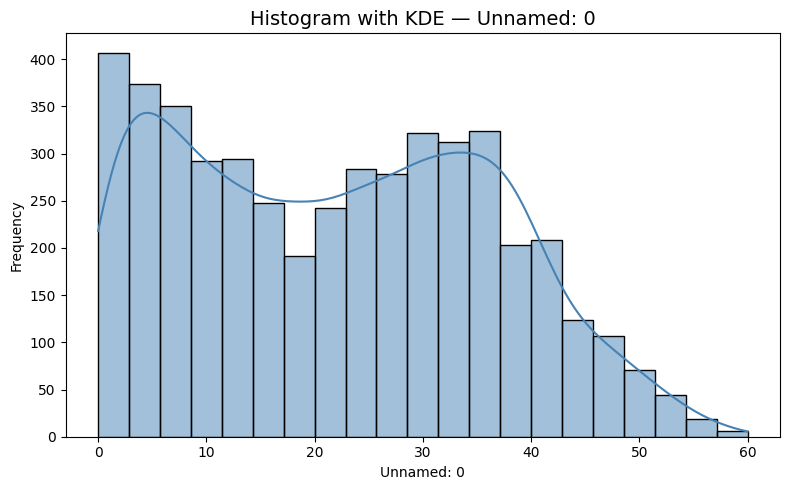

In [46]:
num_col = df.select_dtypes(include=np.number).columns[0]

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df[num_col].dropna(), kde=True, color='steelblue', ax=ax)
ax.set_title(f'Histogram with KDE — {num_col}', fontsize=14)
ax.set_xlabel(num_col)
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### 7b. Box Plot to visualise the spread and outliers

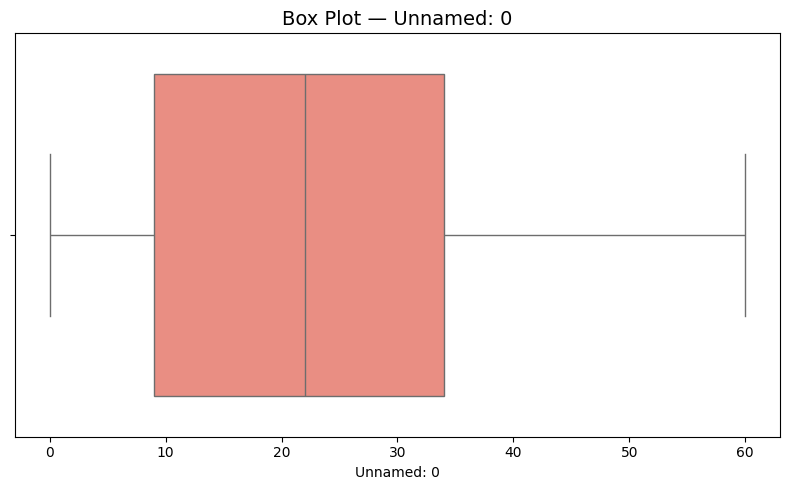

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=df[num_col].dropna(), color='salmon', ax=ax)
ax.set_title(f'Box Plot — {num_col}', fontsize=14)
plt.tight_layout()
plt.show()

### 7c. Calculate skewness of numerical columns

In [48]:
skewness = df.select_dtypes(include=np.number).skew()
print('Skewness of numerical columns:')
print(skewness.sort_values(ascending=False))

Skewness of numerical columns:
pk              2.770088e+00
pkatt           2.489885e+00
fk              1.656387e+00
attendance      1.233996e+00
xg              1.097101e+00
xga             1.097101e+00
ga              1.033734e+00
gf              1.033734e+00
sot             8.878188e-01
dist            7.688121e-01
sh              7.505884e-01
Unnamed: 0      1.812993e-01
date_encoded    5.477454e-02
season          4.933963e-02
poss           -2.256491e-07
notes                    NaN
dtype: float64


### 7d. Identify outliers visually using Box Plots for all numerical columns

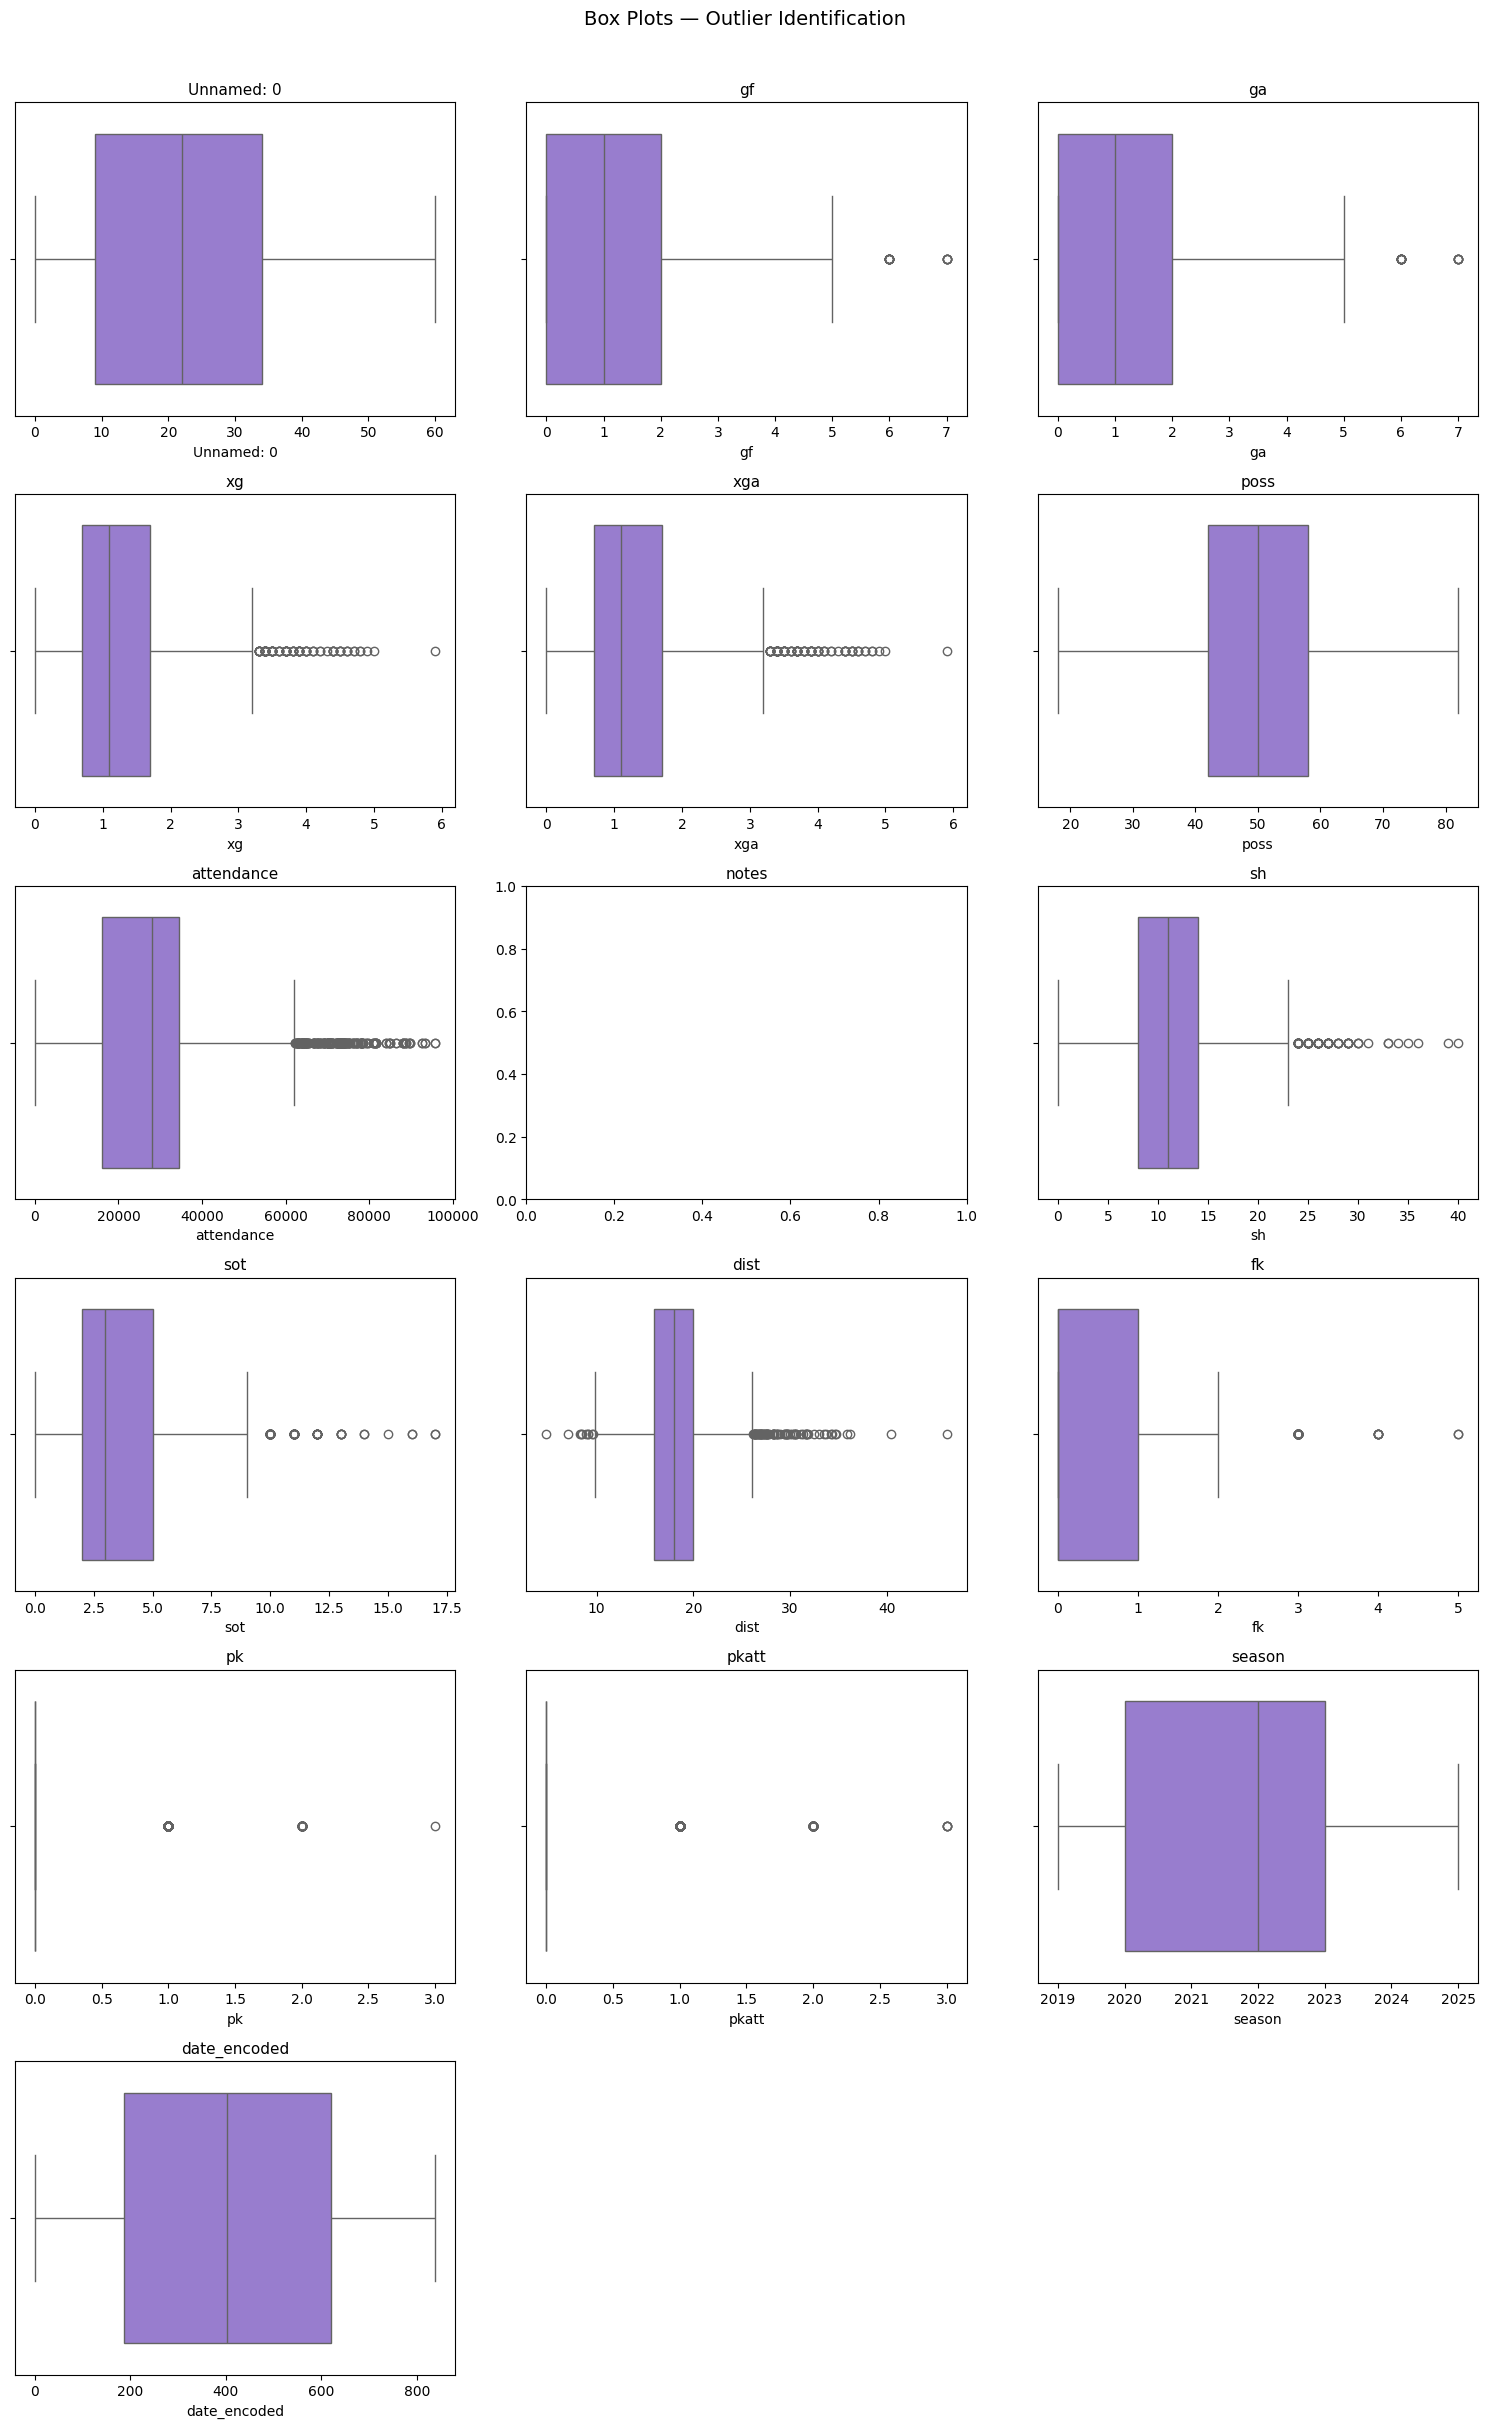

In [49]:
num_cols_list = df.select_dtypes(include=np.number).columns.tolist()
n = len(num_cols_list)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_list):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color='mediumpurple')
    axes[i].set_title(col, fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — Outlier Identification', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Question 8 — Bivariate Analysis

### 8a. Scatter Plot between two numerical variables

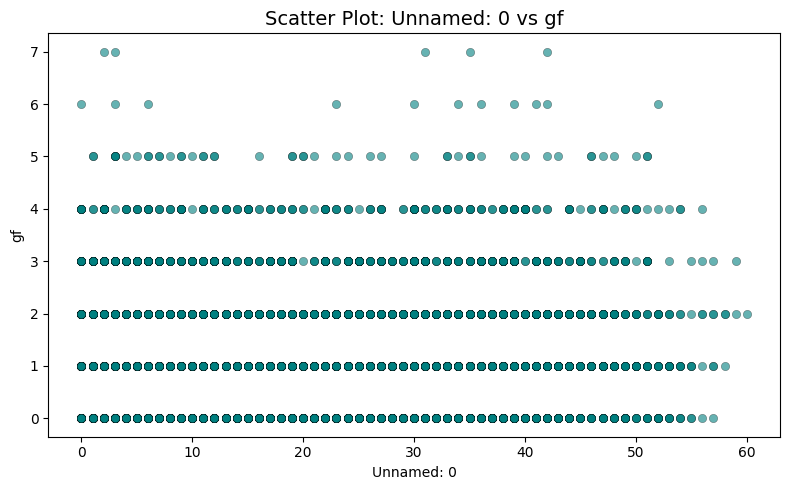

In [50]:
num_cols_list = df.select_dtypes(include=np.number).columns.tolist()
col1, col2 = num_cols_list[0], num_cols_list[1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df[col1], df[col2], alpha=0.6, color='teal', edgecolors='k', linewidths=0.3)
ax.set_xlabel(col1)
ax.set_ylabel(col2)
ax.set_title(f'Scatter Plot: {col1} vs {col2}', fontsize=14)
plt.tight_layout()
plt.show()

### 8b. Pearson Correlation between numerical variables

In [51]:
corr_val, p_val = pearsonr(df[col1].dropna(), df[col2].dropna())
print(f'Pearson Correlation between "{col1}" and "{col2}": {corr_val:.4f}')
print(f'P-value: {p_val:.4f}')

if p_val < 0.05:
    print('Result: Statistically significant correlation.')
else:
    print('Result: No statistically significant correlation.')

Pearson Correlation between "Unnamed: 0" and "gf": 0.0424
P-value: 0.0036
Result: Statistically significant correlation.


### 8c. Violin Plot — Distribution comparison

/tmp/ipykernel_155/3813004938.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x=cat_col, y=num_col, palette='muted', ax=ax)


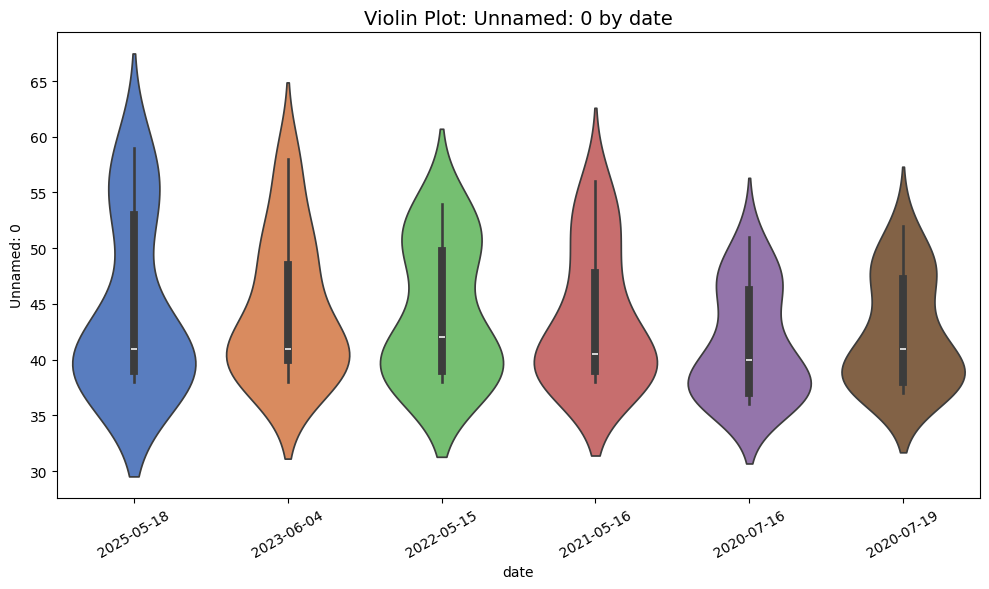

In [52]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

if cat_cols:
    cat_col = cat_cols[0]
    top_cats = df[cat_col].value_counts().index[:6]
    df_violin = df[df[cat_col].isin(top_cats)]
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.violinplot(data=df_violin, x=cat_col, y=num_col, palette='muted', ax=ax)
    ax.set_title(f'Violin Plot: {num_col} by {cat_col}', fontsize=14)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.violinplot(data=df[[col1, col2]], palette='muted', ax=ax)
    ax.set_title('Violin Plot', fontsize=14)
    plt.tight_layout()
    plt.show()

# Question 9 — Multivariate Analysis

### 9a. Pair Plot — Relationships between all numerical variables

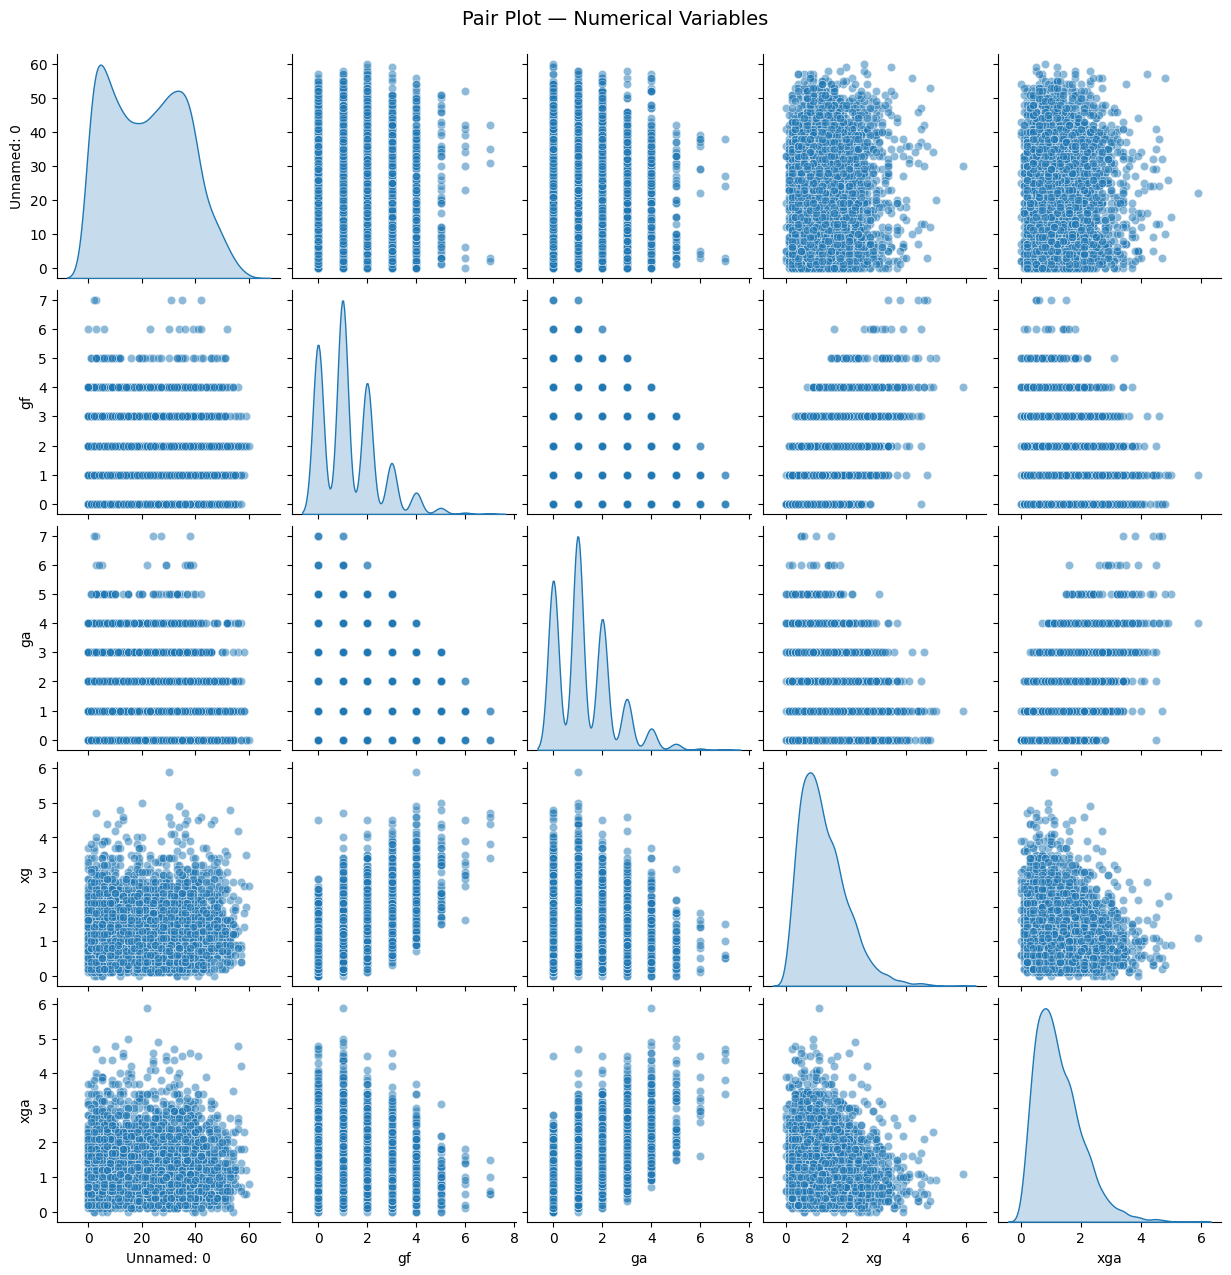

In [53]:
num_subset = df.select_dtypes(include=np.number).iloc[:, :5]
pair_plot = sns.pairplot(num_subset.dropna(), diag_kind='kde', plot_kws={'alpha': 0.5})
pair_plot.fig.suptitle('Pair Plot — Numerical Variables', y=1.02, fontsize=14)
plt.show()

### 9b. Correlation Heatmap with annotations

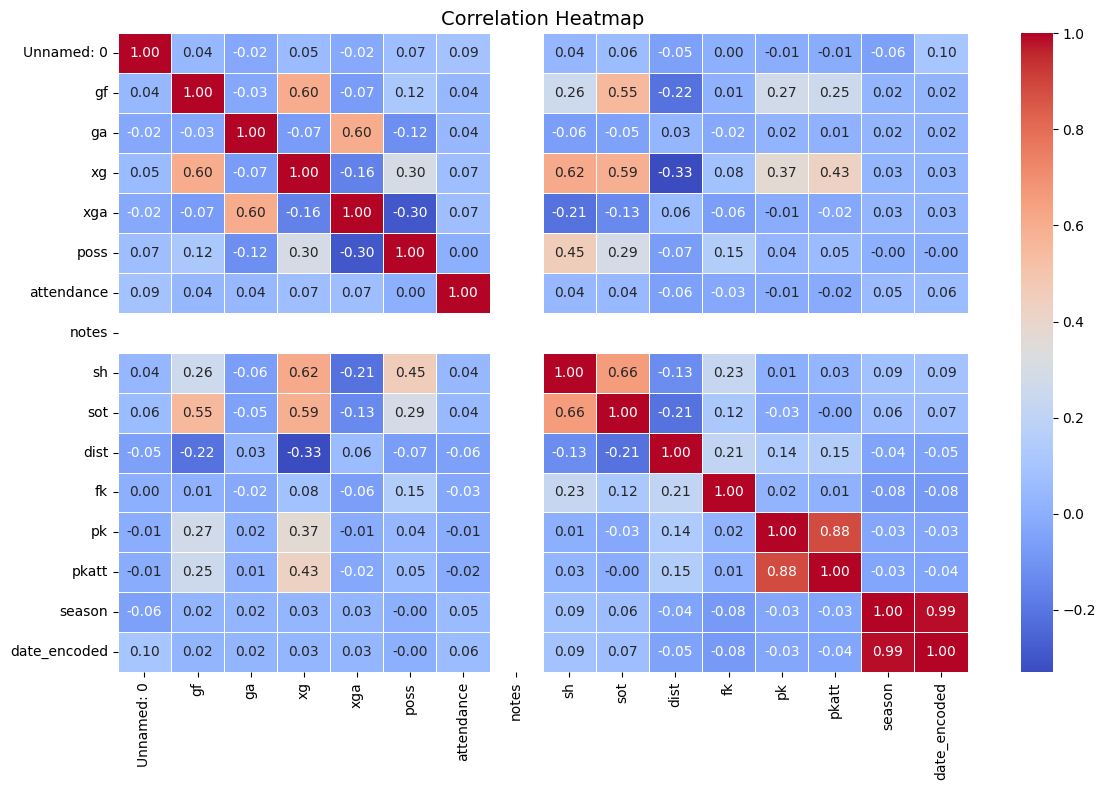

In [54]:
corr_matrix = df.select_dtypes(include=np.number).corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Question 10 — Outlier Detection

### 10a. Z-score method for outlier detection

In [55]:
num_df = df.select_dtypes(include=np.number)

z_scores = np.abs(zscore(num_df.dropna()))
threshold = 3

outlier_mask = (z_scores > threshold)
outlier_counts = outlier_mask.sum(axis=0)

print(f'Outliers detected per column (Z-score > {threshold}):')
print(pd.Series(outlier_counts, index=num_df.columns))

print(f'\nTotal outlier data points: {outlier_mask.sum().sum()}')

Outliers detected per column (Z-score > 3):
Unnamed: 0      0
gf              0
ga              0
xg              0
xga             0
poss            0
attendance      0
notes           0
sh              0
sot             0
dist            0
fk              0
pk              0
pkatt           0
season          0
date_encoded    0
dtype: int64

Total outlier data points: 0


### 10b. Isolation Forest — Anomaly / Outlier Detection

In [57]:
num_df_clean = num_df.fillna(num_df.mean())

iso_forest = IsolationForest(contamination=0.05, random_state=42)
preds_if = iso_forest.fit_predict(num_df_clean)

num_outliers_if = (preds_if == -1).sum()

print(
    f'Isolation Forest — outliers detected: {num_outliers_if}/{len(num_df_clean)} '
    f'({num_outliers_if/len(num_df_clean)*100:.1f}%)'
)

Isolation Forest — outliers detected: 235/4700 (5.0%)


### 10c. Local Outlier Factor (LOF) — Density-based Outlier Detection

LOF — outliers detected: 235/4700 (5.0%)


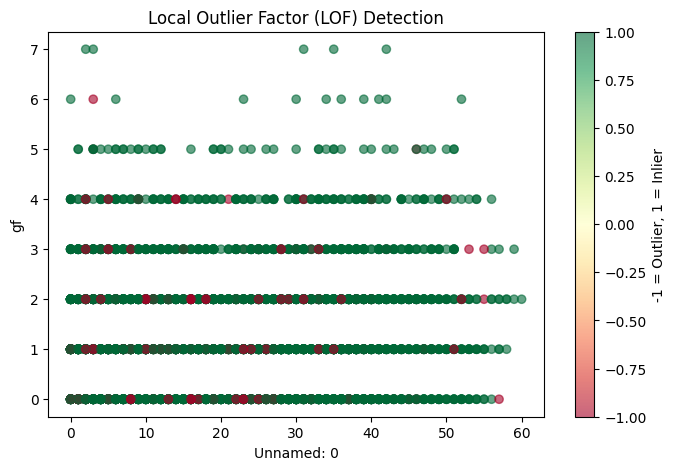

In [60]:
num_df_clean = num_df.dropna(axis=1, how='all')

# fill remaining NaN values
num_df_clean = num_df_clean.fillna(num_df_clean.mean())

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
preds_lof = lof.fit_predict(num_df_clean)

num_outliers_lof = (preds_lof == -1).sum()

print(
    f'LOF — outliers detected: {num_outliers_lof}/{len(num_df_clean)} '
    f'({num_outliers_lof/len(num_df_clean)*100:.1f}%)'
)

fig, ax = plt.subplots(figsize=(8,5))

sc = ax.scatter(
    num_df_clean.iloc[:,0],
    num_df_clean.iloc[:,1],
    c=preds_lof,
    cmap='RdYlGn',
    alpha=0.6
)

ax.set_xlabel(num_df_clean.columns[0])
ax.set_ylabel(num_df_clean.columns[1])
ax.set_title('Local Outlier Factor (LOF) Detection')

plt.colorbar(sc, label='-1 = Outlier, 1 = Inlier')
plt.show()